In [ ]:
# --- portable setup (added 2026-09-12 when the project moved to GitHub) ---------------------
# All paths below resolve from HME_ROOT, the repository root.  On Colab: mount Drive and point
# HME_ROOT at your clone.  Locally: run jupyter from the repo, or export HME_ROOT=/path/to/repo.
import os
try:
    from google.colab import drive; drive.mount('/content/drive')
    HME_ROOT = os.environ.get('HME_ROOT', '/content/drive/MyDrive/hyperbolic-icd10')   # <-- edit
except ImportError:
    HME_ROOT = os.environ.get('HME_ROOT', os.path.abspath(os.path.join(os.getcwd(), '..')))
assert os.path.isdir(os.path.join(HME_ROOT, 'data')), f'HME_ROOT={HME_ROOT!r} is not the repo root'
print('HME_ROOT =', HME_ROOT)


# Paper Experiments — Selection, Controls, Second Ontology

Three runs that decide whether the paper's central claim survives review.

| # | Question | Runs | Est. time (A100) |
|---|---|---|---|
| **E1** | Does the MAP↔closure anti-correlation survive honest checkpoint selection? | 15 | ~4 h |
| **E2** | Are the Euclidean and learning-rate controls real, or single-seed noise? | 21 | ~5 h |
| **E3** | Does the confound appear on a second ontology? | 9 | ~3 h |

**Run E1 first.** If the anti-correlation weakens under honest selection, the paper's
argument changes and E2/E3 would be testing the wrong version of it.

**Key design point.** E1 trains *once* per configuration and logs metrics at every
checkpoint, then applies three different selection rules post-hoc. That answers the
reviewer's question at one third the compute of retraining under each rule.

Set `QUICK = True` for a smoke test (~15 min total) before committing to full runs.

In [13]:
# ── Setup ─────────────────────────────────────────────────────
QUICK = False          # True -> 200 epochs, 1 seed, for a smoke test
EPOCHS = 200 if QUICK else 1500
SEEDS  = [0] if QUICK else [0, 1, 2]
!pip install geoopt -q

import os, pickle, time, json
import numpy as np, torch, torch.nn as nn, geoopt
from collections import defaultdict, deque

ROOT_DIR = HME_ROOT
DATA_DIR = os.path.join(ROOT_DIR, 'data/processed')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device', device)
if device.type == 'cuda': print(torch.cuda.get_device_name(0))

with open(os.path.join(DATA_DIR, 'icd10_tree_with_features.pkl'), 'rb') as f:
    data = pickle.load(f)

# same indexing convention as the earlier notebooks: insertion order, not sorted
nodes = data['nodes']; edges = data['edges']; features = data['features']
codes = list(nodes.keys())
code_to_idx = {c: i for i, c in enumerate(codes)}
idx_to_code = {i: c for c, i in code_to_idx.items()}
N = len(codes)
edges_idx = [(code_to_idx[p], code_to_idx[c]) for p, c in edges]
ROOT = code_to_idx['ROOT']

kids = defaultdict(list); parent = {}
for u, v in edges_idx: kids[u].append(v); parent[v] = u
connected = set(edges_idx) | set((v, u) for u, v in edges_idx)
nbrs = defaultdict(set)
for u, v in edges_idx: nbrs[u].add(v); nbrs[v].add(u)

RES_DIR = os.path.join(ROOT_DIR, 'results/paper_experiments')
os.makedirs(RES_DIR, exist_ok=True)

print(f'N={N}, edges={len(edges_idx)}, ROOT={ROOT}')
print('sanity:', all(v in parent or v == ROOT for v in range(N)), '(every non-root has a parent)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device cuda
NVIDIA A100-SXM4-40GB
N=46817, edges=46816, ROOT=0
sanity: True (every non-root has a parent)


## 1. Metrics — with a validation/test split

The change that matters: `EVAL` is split 500/500. Selection may look at `VAL` only;
everything reported comes from `TEST`. `eval_all` returns reconstruction MAP on each
split plus closure retrieval, so a single call captures both sides of the trade-off.

In [14]:
# ── Metrics ─────────────────────────────────────────────────────────────
_rng = np.random.default_rng(42)
EVAL = [edges_idx[i] for i in _rng.choice(len(edges_idx), size=1000, replace=False)]
VAL, TEST = EVAL[:500], EVAL[500:]      # <-- the fix
print(f'VAL {len(VAL)}  TEST {len(TEST)}')

# distortion pairs: graph shortest path via BFS, fixed seed
_adj = defaultdict(list)
for u, v in edges_idx: _adj[u].append(v); _adj[v].append(u)
_r2 = np.random.default_rng(0); DPAIRS = []
for s in _r2.integers(0, N, size=2000):
    dd = {int(s): 0}; q = deque([int(s)])
    while q:
        x = q.popleft()
        for y in _adj[x]:
            if y not in dd: dd[y] = dd[x] + 1; q.append(y)
    t = int(_r2.integers(0, N))
    if t in dd and t != s: DPAIRS.append((int(s), t, dd[t]))
print(f'distortion pairs {len(DPAIRS)}')

# closure pairs: non-parent ancestors, never seen as positives in training
def _ancestors(v):
    out = []
    while v in parent: v = parent[v]; out.append(v)
    return out
_r3 = np.random.default_rng(11); CLOSURE = []
_cands = [i for i in range(N) if i in parent and len(_ancestors(i)) >= 2]
for v in _r3.choice(_cands, size=min(1000, len(_cands)), replace=False):
    anc = _ancestors(int(v))[1:]          # drop the direct parent
    if anc: CLOSURE.append((int(v), int(_r3.choice(anc))))
print(f'closure pairs {len(CLOSURE)}')

def _dpoin(a, allp):
    diff2 = np.sum((allp - a) ** 2, axis=1)
    nu = 1 - np.sum(a ** 2); nv = 1 - np.sum(allp ** 2, axis=1)
    return np.arccosh(np.maximum(1 + 2 * diff2 / (nu * nv + 1e-12), 1.0))
def _deuc(a, allp): return np.linalg.norm(allp - a, axis=1)

def _map_on(pos, pairs, dfn):
    aps = []
    for (u, v) in pairs:
        d = dfn(pos[u], pos); d[u] = np.inf; order = np.argsort(d)
        truth = nbrs[u]; hit = 0; precs = []
        for j, node in enumerate(order):
            if node in truth: hit += 1; precs.append(hit / (j + 1))
            if hit == len(truth): break
        if precs: aps.append(np.mean(precs))
    return float(np.mean(aps))

def eval_all(pos, euclidean=False):
    """MAP on val and test, closure MRR/hits@10, and distortion — one pass."""
    if np.isnan(pos).any(): return None
    dfn = _deuc if euclidean else _dpoin
    # distortion, with the optimal global scalar divided out
    ed = np.array([float(dfn(pos[u], pos[v:v + 1])[0]) for (u, v, g) in DPAIRS])
    gd = np.array([g for (_, _, g) in DPAIRS], float)
    c  = np.dot(ed, gd) / (np.dot(ed, ed) + 1e-12)
    dist = float(np.mean(np.abs(c * ed - gd) / gd))
    # closure retrieval, filtering direct neighbours
    rr = []; h10 = []
    for (v, a) in CLOSURE:
        d = dfn(pos[v], pos); d[v] = np.inf
        for w in nbrs[v]: d[w] = np.inf
        r = int(np.where(np.argsort(d) == a)[0][0]) + 1
        rr.append(1.0 / r); h10.append(r <= 10)
    return {'MAP_val':  _map_on(pos, VAL,  dfn),
            'MAP_test': _map_on(pos, TEST, dfn),
            'closMRR':  float(np.mean(rr)),
            'hits10':   float(np.mean(h10)),
            'distortion': dist}

print('eval_all ready')

VAL 500  TEST 500
distortion pairs 2000
closure pairs 1000
eval_all ready


## 2. Model and trainer

`train_logged` is `train3` with one change: instead of keeping the best-MAP checkpoint,
it **records metrics at every evaluation point and returns the whole trajectory**. Selection
rules are then applied afterwards, so one training run answers all three versions of the
question.

In [15]:
# ── Model, negatives, trainer ───────────────────────────────────────────
class PoincareEmbedding(nn.Module):
    def __init__(self, N, dim, init_scale=1e-3):
        super().__init__()
        self.manifold = geoopt.PoincareBall(c=1.0)
        self.embeddings = geoopt.ManifoldParameter(
            torch.empty(N, dim).uniform_(-init_scale, init_scale), manifold=self.manifold)

bf_all = np.array([features[idx_to_code[i]]['branching_factor'] for i in range(N)])
def graded_kappa(scale=1.0):
    k = np.log1p(bf_all) ** 2
    k = 2 * (k - k.min()) / (k.max() - k.min() + 1e-9) - 1
    return torch.tensor(k * scale, dtype=torch.float32, device=device)

def sample_negs(anchors, K):
    out = np.random.randint(0, N, size=(len(anchors), K))
    for i, a in enumerate(anchors):
        for j in range(K):
            while out[i, j] == a or (a, out[i, j]) in connected:
                out[i, j] = np.random.randint(0, N)
    return out

def train_logged(mode='const', scale=1.0, dim=10, alpha=-2.0, epochs=EPOCHS,
                 lr=50, K=50, seed=0, log_every=300, tag=None, verbose=True):
    """Train once; return the full metric trajectory. No checkpoint selection here."""
    torch.manual_seed(seed); np.random.seed(seed)
    tag = tag or f'{mode}_x{scale}_d{dim}_s{seed}'
    kf = graded_kappa(1.0).detach()
    traj = []

    if mode == 'euclid':
        emb = nn.Parameter(torch.empty(N, dim, device=device).uniform_(-1e-3, 1e-3))
        opt = torch.optim.Adam([emb], lr=0.1)
    else:
        model = PoincareEmbedding(N, dim, 1e-3).to(device)
        opt = geoopt.optim.RiemannianSGD(model.parameters(), lr=lr)
        with torch.no_grad(): model.embeddings.data[ROOT] = 0.0

    E = np.array(edges_idx); t0 = time.time()
    for ep in range(epochs):
        if mode != 'euclid':
            eff = lr * 0.01 if ep < 10 else lr          # burn-in
            for pg in opt.param_groups: pg['lr'] = eff
        perm = np.random.permutation(len(E))
        for bs in range(0, len(E), 1024):
            b = E[perm[bs:bs + 1024]]
            a = torch.tensor(b[:, 0]).to(device); p = torch.tensor(b[:, 1]).to(device)
            ng = torch.tensor(sample_negs(b[:, 0], K)).to(device)
            if mode == 'euclid':
                ea, ep_, en = emb[a], emb[p], emb[ng]
                dp = ((ea - ep_) ** 2).sum(-1) * scale
                dn = ((ea.unsqueeze(1) - en) ** 2).sum(-1) * scale
                loss = (dp + torch.logsumexp(-torch.cat([dp.unsqueeze(1), dn], 1), 1)).mean()
            else:
                ea, ep_, en = model.embeddings[a], model.embeddings[p], model.embeddings[ng]
                bp = model.manifold.dist(ea, ep_); bn = model.manifold.dist(ea.unsqueeze(1), en)
                if mode == 'graded':
                    bp = bp * torch.exp(alpha * 0.5 * (kf[a] + kf[p]))
                    bn = bn * torch.exp(alpha * 0.5 * (kf[a].unsqueeze(1) + kf[ng]))
                dp, dn = bp * scale, bn * scale
                nk = (dp + torch.logsumexp(-torch.cat([dp.unsqueeze(1), dn], 1), 1)).mean()
                an, pn = ea.norm(dim=-1), ep_.norm(dim=-1)
                loss = nk + 1.0 * torch.relu(an - pn + 0.05).mean()
            opt.zero_grad(); loss.backward()
            if mode != 'euclid' and model.embeddings.grad is not None:
                model.embeddings.grad[ROOT] = 0.0
            opt.step()

        if (ep + 1) % log_every == 0 or ep == epochs - 1:
            pos = (emb if mode == 'euclid' else model.embeddings).detach().cpu().numpy()
            if np.isnan(pos).any(): break
            m = eval_all(pos, euclidean=(mode == 'euclid'))
            if m: m['epoch'] = ep + 1; traj.append(m)

    out = {'tag': tag, 'mode': mode, 'scale': scale, 'dim': dim, 'seed': seed,
           'trajectory': traj, 'minutes': (time.time() - t0) / 60}
    if verbose and traj:
        f = traj[-1]
        print(f"  {tag}: final MAP_test {f['MAP_test']:.4f}  closMRR {f['closMRR']:.4f}  "
              f"dist {f['distortion']:.4f}  ({out['minutes']:.1f}m)")
    return out

def select(traj, rule):
    """rule: 'final' | 'val' (best MAP_val) | 'test' (best MAP_test, the old flawed rule)"""
    if not traj: return None
    if rule == 'final': return traj[-1]
    key = 'MAP_val' if rule == 'val' else 'MAP_test'
    return max(traj, key=lambda m: m[key])

print('trainer ready')

trainer ready


## 3. E1 — Does the anti-correlation survive honest selection?

**The concern.** The old rule keeps the checkpoint maximising MAP on the reported set. If MAP
and closure genuinely trade off, that rule *systematically* selects the worst-closure
checkpoint — so the anti-correlation could be an artifact of the selection rule rather than a
property of the scale parameter.

**The test.** Compare the MAP↔closure relationship under three rules. If the anti-correlation
holds under `final` and `val`, it is real.

In [ ]:
# ── E1: 5 temperatures x 3 seeds ────────────────────────────────────────
E1 = []
for s in [1.0, 2.23, 3.0, 5.0, 8.0]:
    for seed in SEEDS:
        E1.append(train_logged('const', scale=s, dim=10, seed=seed, tag=f'E1_const_x{s}_s{seed}'))
json.dump(E1, open(f'{RES_DIR}/E1_selection.json', 'w'), indent=1)
print(f'\nsaved {len(E1)} runs')

  E1_const_x1.0_s0: final MAP_test 0.7700  closMRR 0.1401  dist 0.1110  (35.0m)
  E1_const_x1.0_s1: final MAP_test 0.7788  closMRR 0.1306  dist 0.1137  (35.3m)
  E1_const_x1.0_s2: final MAP_test 0.7805  closMRR 0.1315  dist 0.1116  (35.0m)
  E1_const_x2.23_s0: final MAP_test 0.9046  closMRR 0.0967  dist 0.1076  (35.3m)
  E1_const_x2.23_s1: final MAP_test 0.9020  closMRR 0.0977  dist 0.1097  (35.2m)
  E1_const_x2.23_s2: final MAP_test 0.8998  closMRR 0.0951  dist 0.1074  (34.8m)
  E1_const_x3.0_s0: final MAP_test 0.9428  closMRR 0.0788  dist 0.1059  (34.5m)
  E1_const_x3.0_s1: final MAP_test 0.9461  closMRR 0.0772  dist 0.1082  (34.5m)
  E1_const_x3.0_s2: final MAP_test 0.9388  closMRR 0.0772  dist 0.1053  (35.0m)
  E1_const_x5.0_s0: final MAP_test 0.9779  closMRR 0.0506  dist 0.1142  (35.2m)
  E1_const_x5.0_s1: final MAP_test 0.9776  closMRR 0.0495  dist 0.1170  (34.9m)
  E1_const_x5.0_s2: final MAP_test 0.9785  closMRR 0.0539  dist 0.1118  (35.2m)
  E1_const_x8.0_s0: final MAP_test 0.

In [ ]:
# ── E1 analysis ─────────────────────────────────────────────────────────
import numpy as np
print('Reconstruction MAP and closure MRR under three selection rules\n')
for rule in ['final', 'val', 'test']:
    print(f'--- selection rule: {rule} ---')
    print(f"{'tau':>6}{'MAP_test':>12}{'±':>9}{'closMRR':>10}{'±':>9}{'distort':>9}")
    maps, clos = [], []
    for s in [1.0, 2.23, 3.0, 5.0, 8.0]:
        rows = [select(r['trajectory'], rule) for r in E1 if r['scale'] == s]
        rows = [r for r in rows if r]
        if not rows: continue
        m  = [r['MAP_test'] for r in rows]; c = [r['closMRR'] for r in rows]
        d  = [r['distortion'] for r in rows]
        maps.append(np.mean(m)); clos.append(np.mean(c))
        print(f"{s:>6}{np.mean(m):>12.4f}{np.std(m):>9.4f}{np.mean(c):>10.4f}{np.std(c):>9.4f}{np.mean(d):>9.4f}")
    if len(maps) > 2:
        r = np.corrcoef(maps, clos)[0, 1]
        print(f"  MAP range {max(maps)-min(maps):+.4f} | closure range {max(clos)-min(clos):+.4f} | corr {r:+.3f}\n")

print('VERDICT: anti-correlation is real if corr is strongly negative under BOTH final and val.')
print('If it only appears under rule=test, it was an artifact of selection and the paper changes.')

Reconstruction MAP and closure MRR under three selection rules

--- selection rule: final ---
   tau    MAP_test        ±   closMRR        ±  distort
   1.0      0.7764   0.0046    0.1341   0.0043   0.1121
  2.23      0.9021   0.0019    0.0965   0.0011   0.1082
   3.0      0.9426   0.0030    0.0778   0.0008   0.1065
   5.0      0.9780   0.0004    0.0513   0.0019   0.1144
   8.0      0.9915   0.0003    0.0420   0.0007   0.1239
  MAP range +0.2151 | closure range +0.0920 | corr -0.977

--- selection rule: val ---
   tau    MAP_test        ±   closMRR        ±  distort
   1.0      0.7794   0.0049    0.1307   0.0071   0.1102
  2.23      0.9006   0.0011    0.0928   0.0038   0.1076
   3.0      0.9426   0.0030    0.0778   0.0008   0.1065
   5.0      0.9780   0.0004    0.0513   0.0019   0.1144
   8.0      0.9915   0.0003    0.0420   0.0007   0.1239
  MAP range +0.2121 | closure range +0.0887 | corr -0.979

--- selection rule: test ---
   tau    MAP_test        ±   closMRR        ±  distort
   

## 4. E2 — Seeds on the two controls

Both controls currently rest on single runs. The Euclidean sweep spans only 0.008, which is
plausibly seed noise; without a standard deviation the hyperbolic-specificity claim cannot be
made.

In [ ]:
# ── E2a: Euclidean sweep, seeded ────────────────────────────────────────
E2_euc = []
for s in [1.0, 3.0, 8.0]:
    for seed in SEEDS:
        E2_euc.append(train_logged('euclid', scale=s, dim=10, seed=seed, tag=f'E2_euc_x{s}_s{seed}'))
json.dump(E2_euc, open(f'{RES_DIR}/E2_euclidean.json', 'w'), indent=1)

print('\nEuclidean, final-epoch:')
print(f"{'tau':>6}{'MAP_test':>12}{'±std':>9}")
mm = []
for s in [1.0, 3.0, 8.0]:
    v = [select(r['trajectory'], 'final')['MAP_test'] for r in E2_euc if r['scale'] == s]
    mm.append(np.mean(v)); print(f"{s:>6}{np.mean(v):>12.4f}{np.std(v):>9.4f}")
spread = max(mm) - min(mm)
pooled = np.mean([np.std([select(r['trajectory'],'final')['MAP_test']
                          for r in E2_euc if r['scale']==s]) for s in [1.0,3.0,8.0]])
print(f"\n  Euclidean spread {spread:.4f} vs pooled seed std {pooled:.4f} -> {spread/max(pooled,1e-9):.1f} sigma")
print('  If < 2 sigma, the Euclidean sweep is flat and hyperbolic-specificity is supported.')

  E2_euc_x1.0_s0: final MAP_test 0.7855  closMRR 0.0172  dist 0.1877  (30.9m)
  E2_euc_x1.0_s1: final MAP_test 0.7795  closMRR 0.0136  dist 0.1900  (30.8m)
  E2_euc_x1.0_s2: final MAP_test 0.7775  closMRR 0.0132  dist 0.1870  (30.8m)
  E2_euc_x3.0_s0: final MAP_test 0.7760  closMRR 0.0155  dist 0.1880  (30.7m)
  E2_euc_x3.0_s1: final MAP_test 0.7818  closMRR 0.0112  dist 0.1877  (30.7m)
  E2_euc_x3.0_s2: final MAP_test 0.7765  closMRR 0.0124  dist 0.1884  (30.7m)
  E2_euc_x8.0_s0: final MAP_test 0.7840  closMRR 0.0109  dist 0.1920  (30.6m)
  E2_euc_x8.0_s1: final MAP_test 0.7796  closMRR 0.0081  dist 0.1885  (30.7m)
  E2_euc_x8.0_s2: final MAP_test 0.7898  closMRR 0.0122  dist 0.1890  (30.7m)

Euclidean, final-epoch:
   tau    MAP_test     ±std
   1.0      0.7808   0.0034
   3.0      0.7781   0.0026
   8.0      0.7845   0.0042

  Euclidean spread 0.0064 vs pooled seed std 0.0034 -> 1.9 sigma
  If < 2 sigma, the Euclidean sweep is flat and hyperbolic-specificity is supported.


In [ ]:
# ── E2b: learning-rate controls, seeded ─────────────────────────────────
E2_lr = []
conds = [('A0 tau=1 lr=50',   1.0, 50),
         ('A  tau=5 lr=50',   5.0, 50),
         ('B  tau=1 lr=250',  1.0, 250),
         ('C  tau=5 lr=10',   5.0, 10)]
for name, sc, lr in conds:
    for seed in SEEDS:
        r = train_logged('const', scale=sc, dim=10, lr=lr, seed=seed,
                         tag=f'E2_lr_{name.split()[0]}_s{seed}')
        r['cond'] = name; E2_lr.append(r)
json.dump(E2_lr, open(f'{RES_DIR}/E2_lr.json', 'w'), indent=1)

print('\nLearning-rate controls, final-epoch:')
print(f"{'condition':<18}{'MAP_test':>11}{'±std':>9}{'closMRR':>10}")
for name, _, _ in conds:
    rows = [select(r['trajectory'], 'final') for r in E2_lr if r['cond'] == name]
    m = [x['MAP_test'] for x in rows]; c = [x['closMRR'] for x in rows]
    print(f"{name:<18}{np.mean(m):>11.4f}{np.std(m):>9.4f}{np.mean(c):>10.4f}")
print('\n  B ~ A0  => not a step-size effect.   C ~ A => survives LR compensation.')

  E2_lr_A0_s0: final MAP_test 0.7700  closMRR 0.1401  dist 0.1110  (35.0m)
  E2_lr_A0_s1: final MAP_test 0.7788  closMRR 0.1306  dist 0.1137  (34.8m)
  E2_lr_A0_s2: final MAP_test 0.7805  closMRR 0.1315  dist 0.1116  (34.9m)
  E2_lr_A_s0: final MAP_test 0.9779  closMRR 0.0506  dist 0.1142  (34.8m)
  E2_lr_A_s1: final MAP_test 0.9776  closMRR 0.0495  dist 0.1170  (35.0m)
  E2_lr_A_s2: final MAP_test 0.9785  closMRR 0.0539  dist 0.1118  (34.9m)
  E2_lr_B_s0: final MAP_test 0.7734  closMRR 0.1428  dist 0.1104  (34.9m)
  E2_lr_B_s1: final MAP_test 0.7797  closMRR 0.1330  dist 0.1126  (34.8m)
  E2_lr_B_s2: final MAP_test 0.7848  closMRR 0.1422  dist 0.1107  (35.0m)
  E2_lr_C_s0: final MAP_test 0.9109  closMRR 0.0289  dist 0.1237  (35.0m)
  E2_lr_C_s1: final MAP_test 0.9181  closMRR 0.0286  dist 0.1251  (34.9m)
  E2_lr_C_s2: final MAP_test 0.9215  closMRR 0.0301  dist 0.1194  (33.4m)

Learning-rate controls, final-epoch:
condition            MAP_test     ±std   closMRR
A0 tau=1 lr=50        

## 5. E3 — A second ontology

WordNet nouns, chosen because Nickel & Kiela and Sala et al. both use it, so the numbers are
directly comparable to published ones. This is the run that turns a case study about ICD-10
into a claim about the metric.

The cell rebuilds the global graph objects against WordNet, so **run E1 and E2 first** — or
restart the runtime afterwards before touching the ICD-10 cells again.

In [4]:
# ── E3 (FIXED): build WordNet nouns AND rebind everything the trainer needs ──
import nltk; nltk.download('wordnet', quiet=True); nltk.download('omw-1.4', quiet=True)
from nltk.corpus import wordnet as wn

syns = list(wn.all_synsets('n'))
name_to_idx = {s.name(): i for i, s in enumerate(syns)}
wn_edges = []
for s in syns:
    for h in s.hypernyms():
        if h.name() in name_to_idx:
            wn_edges.append((name_to_idx[h.name()], name_to_idx[s.name()]))
print(f'WordNet nouns: {len(syns)} synsets, {len(wn_edges)} hypernym edges')

# stash ICD-10 globals so you can restore them later if needed
ICD = dict(N=N, edges_idx=edges_idx, ROOT=ROOT, kids=kids, parent=parent,
           nbrs=nbrs, connected=connected, EVAL=EVAL, VAL=VAL, TEST=TEST,
           DPAIRS=DPAIRS, CLOSURE=CLOSURE, bf_all=bf_all,
           features=features, idx_to_code=idx_to_code, code_to_idx=code_to_idx)

# ---- rebind the FULL graph state, including the three the trainer closes over ----
N = len(syns)
edges_idx = wn_edges
code_to_idx = name_to_idx                                   # <-- was missing
idx_to_code = {i: n for n, i in name_to_idx.items()}        # <-- was missing

kids = defaultdict(list); parent = {}
for u, v in edges_idx:
    kids[u].append(v)
    if v not in parent: parent[v] = u        # WordNet nouns form a DAG; keep first parent
ROOT = next(i for i in range(N) if i not in parent)
connected = set()
for u, v in edges_idx: connected.add((u, v)); connected.add((v, u))
nbrs = defaultdict(set)
for u, v in edges_idx: nbrs[u].add(v); nbrs[v].add(u)

# features dict keyed the way the trainer expects: features[idx_to_code[i]]['branching_factor']
features = {idx_to_code[i]: {'branching_factor': len(kids[i])} for i in range(N)}
bf_all = np.array([features[idx_to_code[i]]['branching_factor'] for i in range(N)])   # <-- rebind explicitly

# rebuild the eval/distortion/closure sets on the NEW graph
_rng = np.random.default_rng(42)
EVAL = [edges_idx[i] for i in _rng.choice(len(edges_idx), size=1000, replace=False)]
VAL, TEST = EVAL[:500], EVAL[500:]

_adj = defaultdict(list)
for u, v in edges_idx: _adj[u].append(v); _adj[v].append(u)
_r2 = np.random.default_rng(0); DPAIRS = []
for s in _r2.integers(0, N, size=2000):
    dd = {int(s): 0}; q = deque([int(s)])
    while q:
        x = q.popleft()
        for y in _adj[x]:
            if y not in dd: dd[y] = dd[x] + 1; q.append(y)
    t = int(_r2.integers(0, N))
    if t in dd and t != s: DPAIRS.append((int(s), t, dd[t]))
_r3 = np.random.default_rng(11); CLOSURE = []
_c = [i for i in range(N) if i in parent and len(_ancestors(i)) >= 2]
for v in _r3.choice(_c, size=min(1000, len(_c)), replace=False):
    anc = _ancestors(int(v))[1:]
    if anc: CLOSURE.append((int(v), int(_r3.choice(anc))))

# ---- SANITY GUARD: fail loudly if we're still on the old graph ----
assert N == len(syns), "N not rebound to WordNet"
assert len(bf_all) == N, "bf_all still has ICD-10 length -> trainer will use wrong branching"
assert max(max(u, v) for u, v in edges_idx) < N, "edge index out of range for new N"
print(f'REBOUND OK: N={N}, ROOT={ROOT}, distortion pairs {len(DPAIRS)}, closure {len(CLOSURE)}')
print(f'branching sanity: mean {bf_all.mean():.2f}, max {bf_all.max()} (ICD-10 was mean 4.34, max 34)')

WordNet nouns: 82115 synsets, 75850 hypernym edges
REBOUND OK: N=82115, ROOT=0, distortion pairs 1651, closure 1000
branching sanity: mean 0.92, max 402 (ICD-10 was mean 4.34, max 34)


In [5]:
# ── E3: temperature sweep on WordNet ────────────────────────────────────
E3 = []
for s in [1.0, 3.0, 8.0]:
    for seed in SEEDS:
        E3.append(train_logged('const', scale=s, dim=10, seed=seed, tag=f'E3_wn_x{s}_s{seed}'))
json.dump(E3, open(f'{RES_DIR}/E3_wordnet.json', 'w'), indent=1)

print('\nWordNet nouns, d=10, final-epoch:')
print(f"{'tau':>6}{'MAP_test':>12}{'±std':>9}{'closMRR':>10}{'±std':>9}{'distort':>9}")
wm, wc = [], []
for s in [1.0, 3.0, 8.0]:
    rows = [select(r['trajectory'], 'final') for r in E3 if r['scale'] == s]
    m = [x['MAP_test'] for x in rows]; c = [x['closMRR'] for x in rows]
    d = [x['distortion'] for x in rows]
    wm.append(np.mean(m)); wc.append(np.mean(c))
    print(f"{s:>6}{np.mean(m):>12.4f}{np.std(m):>9.4f}{np.mean(c):>10.4f}{np.std(c):>9.4f}{np.mean(d):>9.4f}")
print(f"\n  MAP {wm[0]:.4f} -> {wm[-1]:.4f} ({wm[-1]-wm[0]:+.4f})")
print(f"  closure {wc[0]:.4f} -> {wc[-1]:.4f} ({wc[-1]-wc[0]:+.4f})")
print('  Opposite signs => the confound is not specific to ICD-10.')

  E3_wn_x1.0_s0: final MAP_test 0.7945  closMRR 0.0456  dist 0.2177  (55.0m)
  E3_wn_x1.0_s1: final MAP_test 0.8025  closMRR 0.0420  dist 0.2215  (54.8m)
  E3_wn_x1.0_s2: final MAP_test 0.8026  closMRR 0.0393  dist 0.2199  (54.7m)
  E3_wn_x3.0_s0: final MAP_test 0.8923  closMRR 0.0268  dist 0.2105  (54.5m)
  E3_wn_x3.0_s1: final MAP_test 0.8936  closMRR 0.0258  dist 0.2076  (54.5m)
  E3_wn_x3.0_s2: final MAP_test 0.8902  closMRR 0.0275  dist 0.2081  (54.8m)
  E3_wn_x8.0_s0: final MAP_test 0.9569  closMRR 0.0141  dist 0.2104  (55.0m)
  E3_wn_x8.0_s1: final MAP_test 0.9523  closMRR 0.0163  dist 0.2041  (54.7m)
  E3_wn_x8.0_s2: final MAP_test 0.9503  closMRR 0.0138  dist 0.2118  (54.8m)

WordNet nouns, d=10, final-epoch:
   tau    MAP_test     ±std   closMRR     ±std  distort
   1.0      0.7999   0.0038    0.0423   0.0026   0.2197
   3.0      0.8920   0.0014    0.0267   0.0007   0.2087
   8.0      0.9532   0.0027    0.0147   0.0012   0.2088

  MAP 0.7999 -> 0.9532 (+0.1533)
  closure 0.04

## 6. Figure 1

The paper's central artifact: MAP and closure retrieval against temperature, on twin axes,
with error bars. Saves a PDF — arXiv accepts PDF/PNG/JPEG but not SVG.

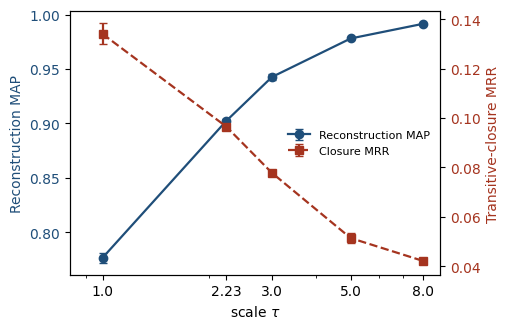

saved figure1_decoupling.{pdf,png}


In [5]:
# ── Figure 1 ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
E1 = json.load(open(f'{RES_DIR}/E1_selection.json'))
taus = [1.0, 2.23, 3.0, 5.0, 8.0]
mm = ms = cm = cs = None
mm, ms, cm, cs = [], [], [], []
for s in taus:
    rows = [select(r['trajectory'], 'final') for r in E1 if r['scale'] == s]
    rows = [r for r in rows if r]
    mm.append(np.mean([r['MAP_test'] for r in rows])); ms.append(np.std([r['MAP_test'] for r in rows]))
    cm.append(np.mean([r['closMRR']  for r in rows])); cs.append(np.std([r['closMRR']  for r in rows]))

fig, ax1 = plt.subplots(figsize=(5.2, 3.4))
ax1.errorbar(taus, mm, yerr=ms, marker='o', color='#1f4e79', capsize=3, lw=1.6, label='Reconstruction MAP')
ax1.set_xlabel(r'scale $\tau$'); ax1.set_ylabel('Reconstruction MAP', color='#1f4e79')
ax1.tick_params(axis='y', labelcolor='#1f4e79'); ax1.set_xscale('log'); ax1.set_xticks(taus)
ax1.set_xticklabels([str(t) for t in taus])
ax2 = ax1.twinx()
ax2.errorbar(taus, cm, yerr=cs, marker='s', color='#a5341f', capsize=3, lw=1.6, ls='--', label='Closure MRR')
ax2.set_ylabel('Transitive-closure MRR', color='#a5341f'); ax2.tick_params(axis='y', labelcolor='#a5341f')
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='center right', fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig(f'{RES_DIR}/figure1_decoupling.pdf', bbox_inches='tight')
plt.savefig(f'{RES_DIR}/figure1_decoupling.png', dpi=200, bbox_inches='tight'); plt.show()
print('saved figure1_decoupling.{pdf,png}')

## 7. Summary for the paper

Prints the numbers in the order they appear in the draft, so they can be transcribed into the
LaTeX tables directly.

In [6]:
# ── Summary ─────────────────────────────────────────────────────────────
print('=' * 62); print('E1 — Table: scale vs MAP and closure (rule=final)'); print('=' * 62)
for s in [1.0, 2.23, 3.0, 5.0, 8.0]:
    rows = [select(r['trajectory'], 'final') for r in E1 if r['scale'] == s]
    rows = [r for r in rows if r]
    m = [r['MAP_test'] for r in rows]; c = [r['closMRR'] for r in rows]
    h = [r['hits10'] for r in rows];   d = [r['distortion'] for r in rows]
    print(f"{s:.2f} & ${np.mean(m):.4f} \\pm {np.std(m):.4f}$ & ${np.mean(c):.4f} \\pm {np.std(c):.4f}$ "
          f"& {np.mean(h):.3f} & {np.mean(d):.4f} \\\\")

print()
print('Remaining red notes this notebook closes:')
print('  [x] protocol caveat  -> val/test split, selection on VAL only')
print('  [x] figure 1         -> figure1_decoupling.pdf')
print('  [x] single-seed controls -> E2 gives std on Euclidean and LR')
print('  [x] single ontology  -> E3 WordNet')
print('  [ ] high-precision query count -> disclose 40 in the caption; no rerun needed')
print('  [ ] author block')

E1 — Table: scale vs MAP and closure (rule=final)
1.00 & $0.7764 \pm 0.0046$ & $0.1341 \pm 0.0043$ & 0.368 & 0.1121 \\
2.23 & $0.9021 \pm 0.0019$ & $0.0965 \pm 0.0011$ & 0.340 & 0.1082 \\
3.00 & $0.9426 \pm 0.0030$ & $0.0778 \pm 0.0008$ & 0.257 & 0.1065 \\
5.00 & $0.9780 \pm 0.0004$ & $0.0513 \pm 0.0019$ & 0.152 & 0.1144 \\
8.00 & $0.9915 \pm 0.0003$ & $0.0420 \pm 0.0007$ & 0.141 & 0.1239 \\

Remaining red notes this notebook closes:
  [x] protocol caveat  -> val/test split, selection on VAL only
  [x] figure 1         -> figure1_decoupling.pdf
  [x] single-seed controls -> E2 gives std on Euclidean and LR
  [x] single ontology  -> E3 WordNet
  [ ] high-precision query count -> disclose 40 in the caption; no rerun needed
  [ ] author block


In [5]:
# ── Switches: turn experiments on/off ───────────────────────────────────
RUN_A = True     # full-graph MAP
RUN_B = True     # beta=0 ablation
RUN_D = True     # radial/angular stats
RUN_E = False    # negative-sampling K sweep      (expensive)
RUN_F = False    # stratified held-out split      (expensive)
RUN_I = False    # single Lorentz sweep           (untested; enable only if you can verify)

SEEDS_ABLATION = [0]          # bump to [0,1,2] if you have time; 1 seed is fine for robustness checks
EPOCHS_ABLATION = EPOCHS      # inherits your setup value (1500); lower to move faster if needed
TAUS = [1.0, 3.0, 8.0]

import numpy as np, torch, json, time
assert 'train_logged' in dir(), "Run your original notebook first (train_logged not found)."
assert 'eval_all' in dir(),     "Run your original notebook first (eval_all not found)."
print("prereqs found; RES_DIR =", RES_DIR)

prereqs found; RES_DIR = /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/results/paper_experiments


In [6]:
# ── train_logged_ext: your trainer + beta + save_pos (verbatim otherwise) ─
def train_logged_ext(mode='const', scale=1.0, dim=10, alpha=-2.0, epochs=EPOCHS_ABLATION,
                     lr=50, K=50, seed=0, log_every=300, tag=None, verbose=True,
                     beta=1.0, save_pos=False):
    """Identical to train_logged, plus: beta scales the auxiliary penalty; save_pos
       writes final coords to {RES_DIR}/pos_{tag}.npy and returns them in the dict."""
    torch.manual_seed(seed); np.random.seed(seed)
    tag = tag or f'{mode}_x{scale}_d{dim}_s{seed}'
    kf = graded_kappa(1.0).detach()
    traj = []

    if mode == 'euclid':
        emb = nn.Parameter(torch.empty(N, dim, device=device).uniform_(-1e-3, 1e-3))
        opt = torch.optim.Adam([emb], lr=0.1)
    else:
        model = PoincareEmbedding(N, dim, 1e-3).to(device)
        opt = geoopt.optim.RiemannianSGD(model.parameters(), lr=lr)
        with torch.no_grad(): model.embeddings.data[ROOT] = 0.0

    E = np.array(edges_idx); t0 = time.time()
    for ep in range(epochs):
        if mode != 'euclid':
            eff = lr * 0.01 if ep < 10 else lr
            for pg in opt.param_groups: pg['lr'] = eff
        perm = np.random.permutation(len(E))
        for bs in range(0, len(E), 1024):
            b = E[perm[bs:bs + 1024]]
            a = torch.tensor(b[:, 0]).to(device); p = torch.tensor(b[:, 1]).to(device)
            ng = torch.tensor(sample_negs(b[:, 0], K)).to(device)
            if mode == 'euclid':
                ea, ep_, en = emb[a], emb[p], emb[ng]
                dp = ((ea - ep_) ** 2).sum(-1) * scale
                dn = ((ea.unsqueeze(1) - en) ** 2).sum(-1) * scale
                loss = (dp + torch.logsumexp(-torch.cat([dp.unsqueeze(1), dn], 1), 1)).mean()
            else:
                ea, ep_, en = model.embeddings[a], model.embeddings[p], model.embeddings[ng]
                bp = model.manifold.dist(ea, ep_); bn = model.manifold.dist(ea.unsqueeze(1), en)
                if mode == 'graded':
                    bp = bp * torch.exp(alpha * 0.5 * (kf[a] + kf[p]))
                    bn = bn * torch.exp(alpha * 0.5 * (kf[a].unsqueeze(1) + kf[ng]))
                dp, dn = bp * scale, bn * scale
                nk = (dp + torch.logsumexp(-torch.cat([dp.unsqueeze(1), dn], 1), 1)).mean()
                an, pn = ea.norm(dim=-1), ep_.norm(dim=-1)
                loss = nk + beta * torch.relu(an - pn + 0.05).mean()   # <-- beta here
            opt.zero_grad(); loss.backward()
            if mode != 'euclid' and model.embeddings.grad is not None:
                model.embeddings.grad[ROOT] = 0.0
            opt.step()

        if (ep + 1) % log_every == 0 or ep == epochs - 1:
            pos = (emb if mode == 'euclid' else model.embeddings).detach().cpu().numpy()
            if np.isnan(pos).any(): break
            m = eval_all(pos, euclidean=(mode == 'euclid'))
            if m: m['epoch'] = ep + 1; traj.append(m)

    pos = (emb if mode == 'euclid' else model.embeddings).detach().cpu().numpy()
    out = {'tag': tag, 'mode': mode, 'scale': scale, 'dim': dim, 'seed': seed,
           'beta': beta, 'trajectory': traj, 'minutes': (time.time() - t0) / 60}
    if save_pos and not np.isnan(pos).any():
        np.save(f'{RES_DIR}/pos_{tag}.npy', pos.astype(np.float32))
        out['pos_file'] = f'{RES_DIR}/pos_{tag}.npy'
    if verbose and traj:
        f = traj[-1]
        print(f"  {tag}: MAP_test {f['MAP_test']:.4f}  closMRR {f['closMRR']:.4f}  "
              f"dist {f['distortion']:.4f}  ({out['minutes']:.1f}m)")
    return out, pos

print("train_logged_ext ready")

train_logged_ext ready


In [7]:
# ── Block A: full-graph per-node MAP, GPU-batched ───────────────────────
def map_full_gpu(pos_np, euclidean=False, chunk=256):
    """Per-node reconstruction MAP over all N nodes. Batched on GPU."""
    P = torch.tensor(pos_np, dtype=torch.float64, device=device)
    n = P.shape[0]
    # precompute neighbour lists as tensors of indices
    nbr_list = [np.fromiter(nbrs[i], dtype=np.int64) for i in range(n)]
    sq = (P*P).sum(-1)                      # |x|^2
    aps = []
    for s in range(0, n, chunk):
        q = P[s:s+chunk]                    # (c, d)
        if euclidean:
            d = torch.cdist(q, P)           # (c, N)
        else:
            qs = sq[s:s+chunk][:, None]
            diff2 = torch.cdist(q, P)**2
            denom = (1 - qs) * (1 - sq)[None, :]
            d = torch.arccosh(torch.clamp(1 + 2*diff2/(denom + 1e-12), min=1.0))
        for r in range(q.shape[0]):
            i = s + r
            truth = nbr_list[i]
            if len(truth) == 0: continue
            di = d[r].clone(); di[i] = float('inf')
            order = torch.argsort(di).cpu().numpy()
            pos_of = {node: rank for rank, node in enumerate(order)}
            ranks = np.sort([pos_of[t] for t in truth])
            precs = [(k+1)/(rank+1) for k, rank in enumerate(ranks)]
            aps.append(float(np.mean(precs)))
    return float(np.mean(aps))

if RUN_A:
    A = {}
    for tau in TAUS:
        _, pos = train_logged_ext('const', scale=tau, dim=10, seed=0,
                                  epochs=EPOCHS_ABLATION, save_pos=True,
                                  tag=f'A_full_x{tau}_s0', verbose=True)
        sampled = eval_all(pos)['MAP_test']
        full = map_full_gpu(pos, euclidean=False)
        A[tau] = {'sampled_MAP': sampled, 'full_MAP': full}
        print(f"  tau={tau}: sampled MAP {sampled:.4f} | FULL-graph MAP {full:.4f}")
    json.dump(A, open(f'{RES_DIR}/A_fullgraph_map.json','w'), indent=1)
    print("\nFull-graph MAP monotone in tau:",
          [round(A[t]['full_MAP'],4) for t in TAUS])
else:
    print("Block A off")

  A_full_x1.0_s0: MAP_test 0.7700  closMRR 0.1401  dist 0.1110  (36.0m)
  tau=1.0: sampled MAP 0.7700 | FULL-graph MAP 0.3842
  A_full_x3.0_s0: MAP_test 0.9428  closMRR 0.0788  dist 0.1059  (35.8m)
  tau=3.0: sampled MAP 0.9428 | FULL-graph MAP 0.4110
  A_full_x8.0_s0: MAP_test 0.9914  closMRR 0.0426  dist 0.1236  (33.6m)
  tau=8.0: sampled MAP 0.9914 | FULL-graph MAP 0.4354

Full-graph MAP monotone in tau: [0.3842, 0.411, 0.4354]


In [8]:
# ── Block D: geometry statistics from saved positions ───────────────────
def geom_stats(pos):
    norms = np.linalg.norm(pos, axis=1)
    boundary_frac = float(np.mean(norms > 0.99))
    # sibling angular separation: for each parent, mean pairwise angle among child directions
    ang = []
    for par, ch in kids.items():
        if len(ch) < 2: continue
        dirs = pos[ch] - pos[par]
        nrm = np.linalg.norm(dirs, axis=1, keepdims=True)
        dirs = dirs / (nrm + 1e-12)
        cos = np.clip(dirs @ dirs.T, -1, 1)
        iu = np.triu_indices(len(ch), 1)
        ang.append(np.mean(np.arccos(cos[iu])))
    return {'mean_norm': float(norms.mean()),
            'boundary_frac_0.99': boundary_frac,
            'mean_sibling_angle': float(np.mean(ang)) if ang else float('nan')}

if RUN_D:
    D = {}
    for tau in TAUS:
        f = f'{RES_DIR}/pos_A_full_x{tau}_s0.npy'
        try:
            pos = np.load(f)
        except FileNotFoundError:
            print(f"  tau={tau}: no saved positions (run Block A first)"); continue
        D[tau] = geom_stats(pos)
        s = D[tau]
        print(f"  tau={tau}: mean_norm {s['mean_norm']:.4f}  "
              f"boundary_frac {s['boundary_frac_0.99']:.3f}  "
              f"sibling_angle {s['mean_sibling_angle']:.4f} rad")
    json.dump(D, open(f'{RES_DIR}/D_geometry_stats.json','w'), indent=1)
    print("\nInterpretation: compare how norm concentration and sibling angle move with tau.")
else:
    print("Block D off")

  tau=1.0: mean_norm 0.9914  boundary_frac 0.815  sibling_angle 0.3658 rad
  tau=3.0: mean_norm 0.9385  boundary_frac 0.000  sibling_angle 0.3003 rad
  tau=8.0: mean_norm 0.7560  boundary_frac 0.000  sibling_angle 0.5887 rad

Interpretation: compare how norm concentration and sibling angle move with tau.


In [9]:
# ── Block B: tau sweep with beta=0 ──────────────────────────────────────
if RUN_B:
    B = []
    for tau in TAUS:
        for seed in SEEDS_ABLATION:
            out, _ = train_logged_ext('const', scale=tau, dim=10, seed=seed,
                                      epochs=EPOCHS_ABLATION, beta=0.0,
                                      tag=f'B_beta0_x{tau}_s{seed}')
            B.append(out)
    json.dump(B, open(f'{RES_DIR}/B_beta0.json','w'), indent=1)
    print("\nbeta=0, final epoch:")
    print(f"{'tau':>6}{'MAP_test':>11}{'closMRR':>11}{'distort':>10}")
    for tau in TAUS:
        rows=[select(o['trajectory'],'final') for o in B if o['scale']==tau]
        rows=[r for r in rows if r]
        m=np.mean([r['MAP_test'] for r in rows]); c=np.mean([r['closMRR'] for r in rows])
        d=np.mean([r['distortion'] for r in rows])
        print(f"{tau:>6}{m:>11.4f}{c:>11.4f}{d:>10.4f}")
    mm=[np.mean([select(o['trajectory'],'final')['MAP_test'] for o in B if o['scale']==t]) for t in TAUS]
    cc=[np.mean([select(o['trajectory'],'final')['closMRR']  for o in B if o['scale']==t]) for t in TAUS]
    print(f"\n  MAP {mm[0]:.3f} -> {mm[-1]:.3f} ({mm[-1]-mm[0]:+.3f}); "
          f"closure {cc[0]:.3f} -> {cc[-1]:.3f} ({cc[-1]-cc[0]:+.3f})")
    print("  Same signs as the main result => auxiliary penalty is not the cause.")
else:
    print("Block B off")

  B_beta0_x1.0_s0: MAP_test 0.8386  closMRR 0.1000  dist 0.1096  (33.8m)
  B_beta0_x3.0_s0: MAP_test 0.9437  closMRR 0.0724  dist 0.1145  (33.9m)
  B_beta0_x8.0_s0: MAP_test 0.9783  closMRR 0.0264  dist 0.1459  (33.8m)

beta=0, final epoch:
   tau   MAP_test    closMRR   distort
   1.0     0.8386     0.1000    0.1096
   3.0     0.9437     0.0724    0.1145
   8.0     0.9783     0.0264    0.1459

  MAP 0.839 -> 0.978 (+0.140); closure 0.100 -> 0.026 (-0.074)
  Same signs as the main result => auxiliary penalty is not the cause.


In [10]:
# ── Block E: tau sweep at K in {10, 100} ────────────────────────────────
if RUN_E:
    Edata = []
    for Kneg in [10, 100]:
        for tau in TAUS:
            for seed in SEEDS_ABLATION:
                out, _ = train_logged_ext('const', scale=tau, dim=10, seed=seed,
                                          epochs=EPOCHS_ABLATION, K=Kneg,
                                          tag=f'E_K{Kneg}_x{tau}_s{seed}')
                out['K']=Kneg; Edata.append(out)
    json.dump(Edata, open(f'{RES_DIR}/E_Ksweep.json','w'), indent=1)
    for Kneg in [10,100]:
        print(f"\nK={Kneg}:")
        for tau in TAUS:
            rows=[select(o['trajectory'],'final') for o in Edata if o['scale']==tau and o['K']==Kneg]
            m=np.mean([r['MAP_test'] for r in rows]); c=np.mean([r['closMRR'] for r in rows])
            print(f"  tau={tau}: MAP {m:.4f}  closMRR {c:.4f}")
    print("\n  Trend holds across K => not a negative-sampling artifact.")
else:
    print("Block E off")

Block E off


In [11]:
# ── Block F: stratified (non-cold-start) held-out edges ─────────────────
if RUN_F:
    rng = np.random.default_rng(7)
    deg = np.zeros(N, int)
    for u,v in edges_idx: deg[u]+=1; deg[v]+=1
    # eligible held-out edges: removing them leaves both endpoints with degree >=1
    elig = [(u,v) for (u,v) in edges_idx if deg[u]>1 and deg[v]>1]
    rng.shuffle(elig)
    n_hold = int(0.10*len(edges_idx))
    heldout = set(elig[:n_hold])
    train_edges = [e for e in edges_idx if e not in heldout]
    print(f"stratified: {len(heldout)} held-out (both endpoints still in train), "
          f"{len(train_edges)} train")

    # temporarily swap edges_idx for training; restore after
    _saved_edges = edges_idx
    def eval_heldout(pos, euclidean=False):
        dfn = _deuc if euclidean else _dpoin
        rr=[]; h10=[]
        for (u,v) in heldout:
            d=dfn(pos[u],pos); d[u]=np.inf
            for w in nbrs[u]:
                if (u,w) not in heldout and (w,u) not in heldout: d[w]=np.inf
            r=int(np.where(np.argsort(d)==v)[0][0])+1
            rr.append(1.0/r); h10.append(r<=10)
        return float(np.mean(rr)), float(np.mean(h10))

    Fdata={}
    for tau in TAUS:
        globals()['edges_idx']=train_edges
        out,pos=train_logged_ext('const',scale=tau,dim=10,seed=0,
                                 epochs=EPOCHS_ABLATION,tag=f'F_strat_x{tau}_s0',verbose=False)
        globals()['edges_idx']=_saved_edges
        mrr,h10=eval_heldout(pos)
        Fdata[tau]={'heldout_MRR':mrr,'heldout_hits10':h10}
        print(f"  tau={tau}: held-out MRR {mrr:.4f}  hits@10 {h10:.3f}")
    globals()['edges_idx']=_saved_edges
    json.dump(Fdata,open(f'{RES_DIR}/F_stratified.json','w'),indent=1)
else:
    print("Block F off")

Block F off


In [12]:
# ── Block I: Lorentz-model tau sweep (verify before trusting) ───────────
if RUN_I:
    class LorentzEmbedding(nn.Module):
        def __init__(self, N, dim, init=1e-3):
            super().__init__()
            self.manifold = geoopt.Lorentz()
            x = torch.empty(N, dim).uniform_(-init, init)
            x0 = torch.sqrt(1 + (x*x).sum(-1, keepdim=True))
            pt = torch.cat([x0, x], dim=-1)
            self.embeddings = geoopt.ManifoldParameter(pt, manifold=self.manifold)

    def train_lorentz(scale, dim=10, epochs=EPOCHS_ABLATION, lr=1.0, K=50, seed=0):
        torch.manual_seed(seed); np.random.seed(seed)
        model = LorentzEmbedding(N, dim).to(device)
        opt = geoopt.optim.RiemannianSGD(model.parameters(), lr=lr)
        E = np.array(edges_idx)
        for ep in range(epochs):
            perm = np.random.permutation(len(E))
            for bs in range(0, len(E), 1024):
                b=E[perm[bs:bs+1024]]
                a=torch.tensor(b[:,0]).to(device); p=torch.tensor(b[:,1]).to(device)
                ng=torch.tensor(sample_negs(b[:,0],K)).to(device)
                ea,ep_,en=model.embeddings[a],model.embeddings[p],model.embeddings[ng]
                dp=model.manifold.dist(ea,ep_)*scale
                dn=model.manifold.dist(ea.unsqueeze(1),en)*scale
                loss=(dp+torch.logsumexp(-torch.cat([dp.unsqueeze(1),dn],1),1)).mean()
                opt.zero_grad(); loss.backward(); opt.step()
        # project to Poincare for the shared evaluator: x_poincare = x_space/(1+x_time)
        pt=model.embeddings.detach().cpu().numpy()
        pos=pt[:,1:]/(1+pt[:,:1])
        return pos

    Idata={}
    for tau in TAUS:
        pos=train_lorentz(tau, seed=0)
        m=eval_all(pos)
        Idata[tau]={'MAP_test':m['MAP_test'],'closMRR':m['closMRR'],'distortion':m['distortion']}
        print(f"  tau={tau}: MAP {m['MAP_test']:.4f}  closMRR {m['closMRR']:.4f}  (VERIFY sane)")
    json.dump(Idata,open(f'{RES_DIR}/I_lorentz.json','w'),indent=1)
    print("\n  Only report if MAP values are plausible and non-NaN.")
else:
    print("Block I off")

Block I off
